In [13]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('./Dataset/LengthOfStay.csv')
df.sample(10)

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
30075,30076,9/20/2012,5+,M,0,0,0,0,1,1,...,176.753612,23.0,0.969074,27.558589,81,5.7,0,9/29/2012,E,9
30418,30419,8/2/2012,5+,F,0,0,0,0,0,0,...,178.108901,12.0,0.975415,29.817121,69,6.5,5,8/9/2012,A,7
25007,25008,12/13/2012,1,M,0,1,0,0,0,0,...,79.341876,313.5,0.757932,27.817366,68,6.2,1,12/19/2012,D,6
76337,76338,8/11/2012,0,M,0,0,1,0,1,0,...,170.422556,12.0,0.802727,30.884444,67,6.5,0,8/16/2012,E,5
58468,58469,7/11/2012,0,F,0,0,0,0,1,1,...,137.891119,17.0,0.951856,26.617529,89,6.5,6,7/15/2012,E,4
23172,23173,4/4/2012,0,F,0,0,0,0,0,0,...,127.323678,12.0,1.037269,29.250004,57,6.5,4,4/8/2012,B,4
12045,12046,11/29/2012,1,F,0,0,0,0,0,0,...,176.743082,17.0,0.934771,27.630146,81,6.5,1,12/2/2012,B,3
6920,6921,7/13/2012,3,M,0,0,0,0,0,0,...,172.061834,12.0,1.255876,31.057111,73,6.5,7,7/18/2012,A,5
52509,52510,7/3/2012,0,F,0,0,0,0,1,1,...,164.845921,11.0,0.946325,28.652480,86,6.5,1,7/6/2012,E,3
6673,6674,11/14/2012,2,F,0,0,0,0,0,1,...,138.717722,17.0,1.085262,28.889112,92,6.1,0,11/20/2012,A,6


In [4]:
df.shape

(100000, 28)

In [5]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(df,test_size=0.2,random_state=42)

In [6]:
df_train.shape

(80000, 28)

In [7]:
df_train.duplicated().sum()

np.int64(0)

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   eid                         80000 non-null  int64  
 1   vdate                       80000 non-null  object 
 2   rcount                      80000 non-null  object 
 3   gender                      80000 non-null  object 
 4   dialysisrenalendstage       80000 non-null  int64  
 5   asthma                      80000 non-null  int64  
 6   irondef                     80000 non-null  int64  
 7   pneum                       80000 non-null  int64  
 8   substancedependence         80000 non-null  int64  
 9   psychologicaldisordermajor  80000 non-null  int64  
 10  depress                     80000 non-null  int64  
 11  psychother                  80000 non-null  int64  
 12  fibrosisandother            80000 non-null  int64  
 13  malnutrition                8000

In [9]:
df_train.isnull().sum()

eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
creatinine                    0
bmi                           0
pulse                         0
respiration                   0
secondarydiagnosisnonicd9     0
discharged                    0
facid                         0
lengthofstay                  0
dtype: int64

In [10]:
df_train.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,50022.926437,0.036312,0.034975,0.094750,0.039350,0.062350,0.239325,0.052025,0.049212,0.004625,...,10.176926,137.885929,141.967963,14.106032,1.099373,29.806527,73.456275,6.491869,2.118325,4.001762
std,28869.648875,0.187068,0.183718,0.292871,0.194427,0.241792,0.426674,0.222079,0.216313,0.067850,...,5.145802,3.000821,30.039815,13.121823,0.200289,2.004944,11.661816,0.568923,2.047010,2.364747
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,125.259814,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.000000
25%,25029.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,135.854702,121.657115,11.000000,0.964624,28.452336,66.000000,6.500000,1.000000,2.000000
50%,50047.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.400000,137.889114,142.086522,12.000000,1.098796,29.814477,73.000000,6.500000,1.000000,4.000000
75%,75038.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.500000,139.906375,162.216634,14.000000,1.234741,31.164777,81.000000,6.500000,3.000000,6.000000
max,99999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,245.900000,151.315937,271.444277,682.500000,2.035202,38.935293,126.000000,10.000000,10.000000,17.000000


In [11]:
df_train['lengthofstay'].value_counts()

lengthofstay
1     14416
3     12843
4     11795
2     10273
5      9674
6      8348
7      5765
8      3737
9      1753
10      800
11      371
12      111
13       61
14       29
15       15
16        6
17        3
Name: count, dtype: int64

<Axes: xlabel='lengthofstay', ylabel='Count'>

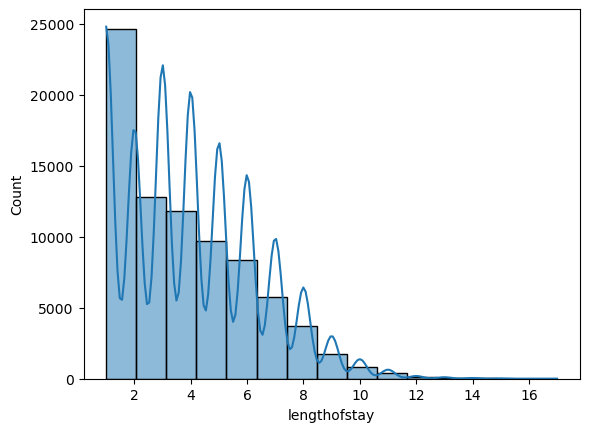

In [15]:
sb.histplot(df_train['lengthofstay'],bins=15,kde='True')

In [16]:
print(f"The skewness of target column is {df_train['lengthofstay'].skew()} and kurtosis is {df_train['lengthofstay'].kurtosis()}")

The skewness of target column is 0.6343562697523857 and kurtosis is 8.752670622769188e-05
